In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv

In [28]:
root_dir = '/content/drive/MyDrive/analysis_data/olist_analysis'

In [29]:
os.chdir (root_dir)

In [30]:
df = pd.read_csv('df.csv', index_col=0)

In [5]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,purchase_year,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,delivery_days,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,2017,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,8.436574,-7.107488,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,2018,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,13.782037,-5.355729,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,2018,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,9.394213,-17.245498,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,2017,...,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,13.208750,-12.980069,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2018,...,316.0,4.0,250.0,51.0,15.0,15.0,stationery,2.873877,-9.238171,False


In [6]:
# сommon featues / общие показатели
print(f"Orders: {df['order_id'].nunique():,}")
print(f"Customers: {df['customer_unique_id'].nunique():,}")
print(f"Products: {df['product_id'].nunique():,}")
print(f"Revenue: ${df['price'].sum():,.2f}")
print(f"Average item price: ${df['price'].mean():,.2f}")

Orders: 99,441
Customers: 56,542
Products: 32,951
Revenue: $13,591,643.70
Average item price: $120.65


In [7]:
# orders analysis/ анализ заказов

# orders by months / заказы по месяцам
monthly_orders = df.groupby('purchase_month').agg(orders = ('order_id', 'nunique'), revenue = ('price', 'sum')).reset_index()
monthly_orders

,purchase_month,orders,revenue
0,2016-09,4,267.36
1,2016-10,324,49507.66
2,2016-12,1,10.90
3,2017-01,800,120312.87
4,2017-02,1780,247303.02
5,2017-03,2682,374344.30
6,2017-04,2404,359927.23
7,2017-05,3700,506071.14
8,2017-06,3245,433038.60
9,2017-07,4026,498031.48


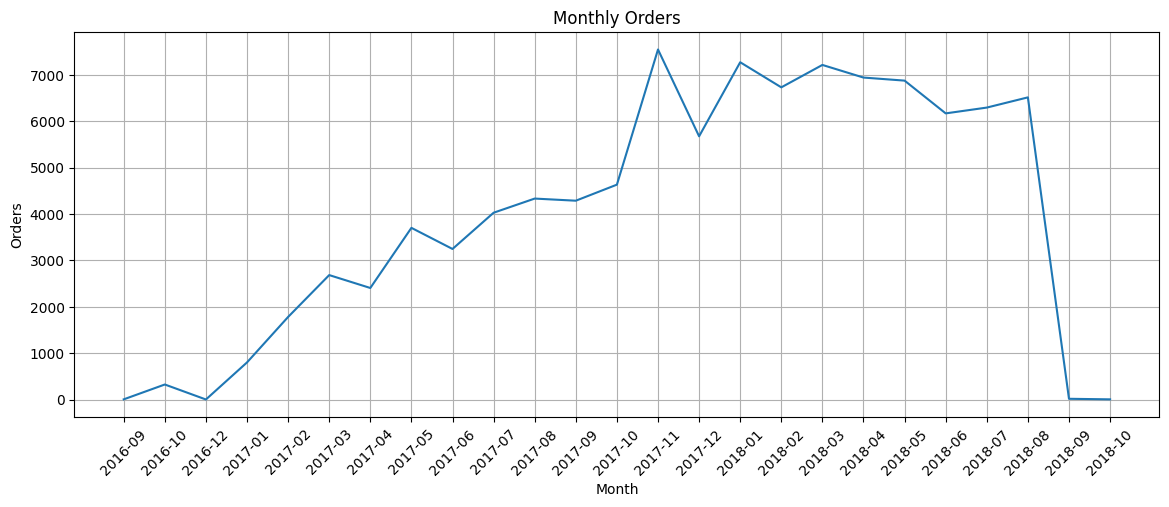

In [8]:
plt.figure(figsize=(14,5))
sns.lineplot(data=monthly_orders, x='purchase_month', y='orders')
plt.title('Monthly Orders')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.grid(axis='both')
plt.show()


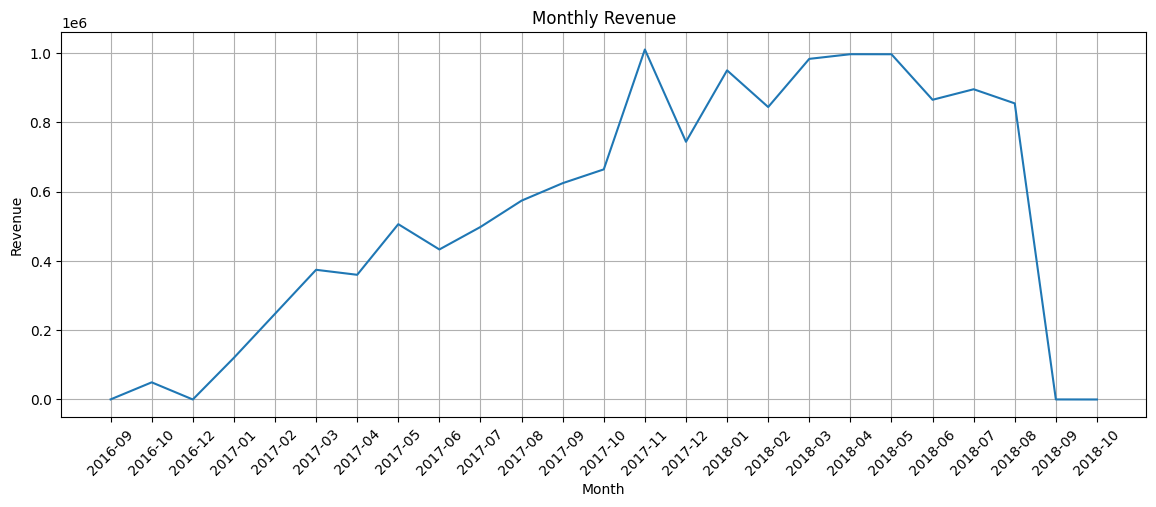

In [9]:
# revenue dynamics / динамика выручки
plt.figure(figsize=(14,5))
plt.xticks(rotation=45)
sns.lineplot(data=monthly_orders, x='purchase_month', y='revenue')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(axis='both')
plt.show()


In [10]:
# items categories / категории товаров
# top-10 categories / топ-10 категорий
top_categories = (
    df.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

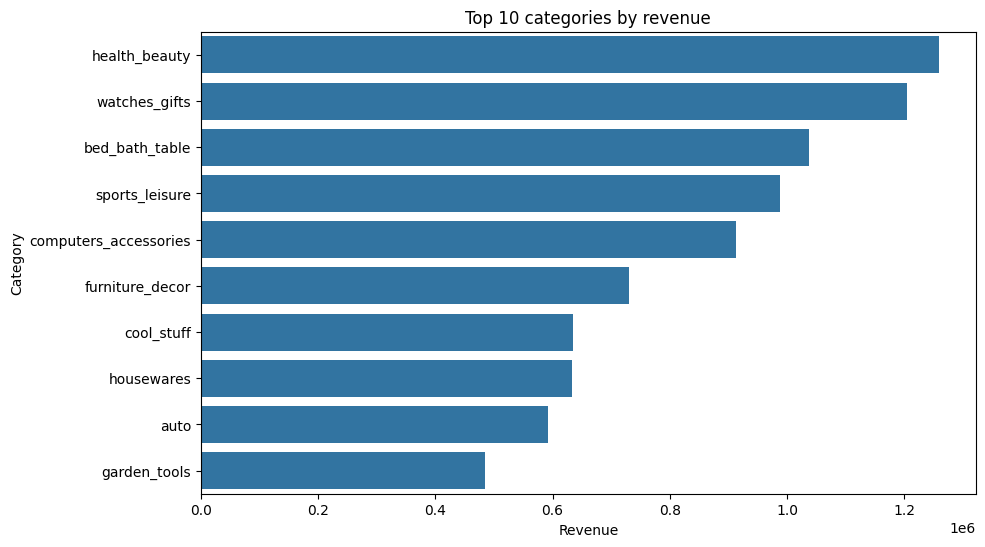

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_categories,
    y='product_category_name_english',
    x='price'
)

plt.title('Top 10 categories by revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.show()

In [12]:
# mean price by category / средняя цена по категориям
category_price = (
    df.groupby('product_category_name_english')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

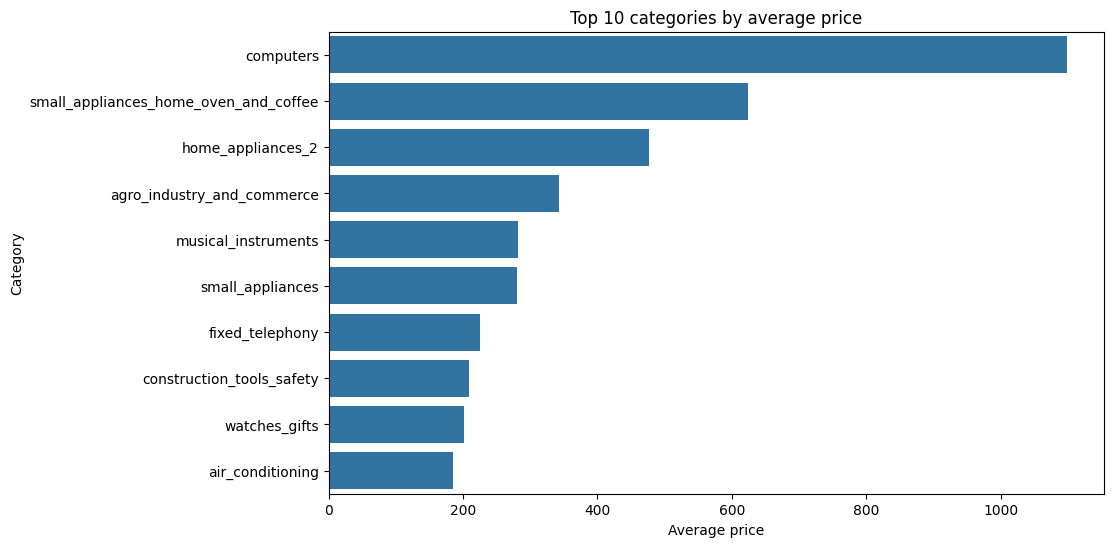

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_price,
    y='product_category_name_english',
    x='price'
)

plt.title('Top 10 categories by average price')
plt.xlabel('Average price')
plt.ylabel('Category')
plt.show()

In [14]:
# clients
# orders distribution / распределение заказов
customer_orders = (
    df.groupby('customer_unique_id')['order_id']
    .nunique()
)

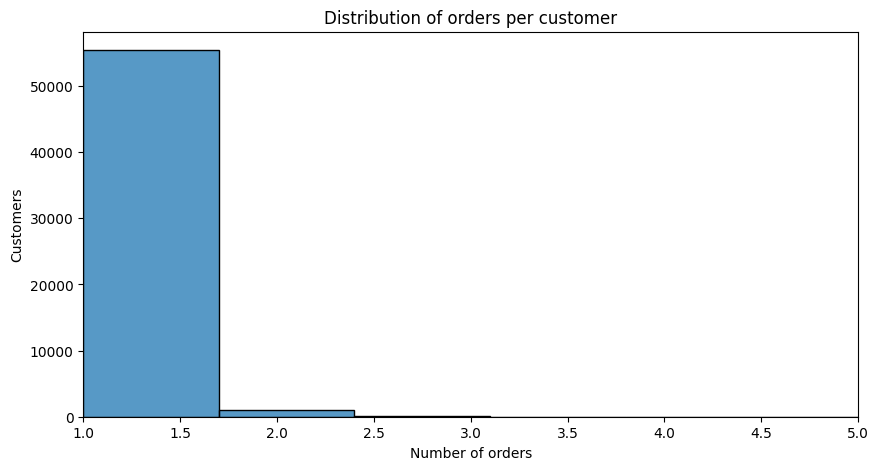

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_orders,
    bins=10
)

plt.xlim(1, 5)
plt.title('Distribution of orders per customer')
plt.xlabel('Number of orders')
plt.ylabel('Customers')
plt.show()

In [16]:
# repeat customers rate / доля повторных клиентов
repeat_rate = (
    (customer_orders > 1).mean() * 100
)

print(f"Repeat customer rate: {repeat_rate:.2f}%")

Repeat customer rate: 1.92%


In [17]:
# geography / география
# customers by states / клиенты по штатам
state_customers = (
    df.groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

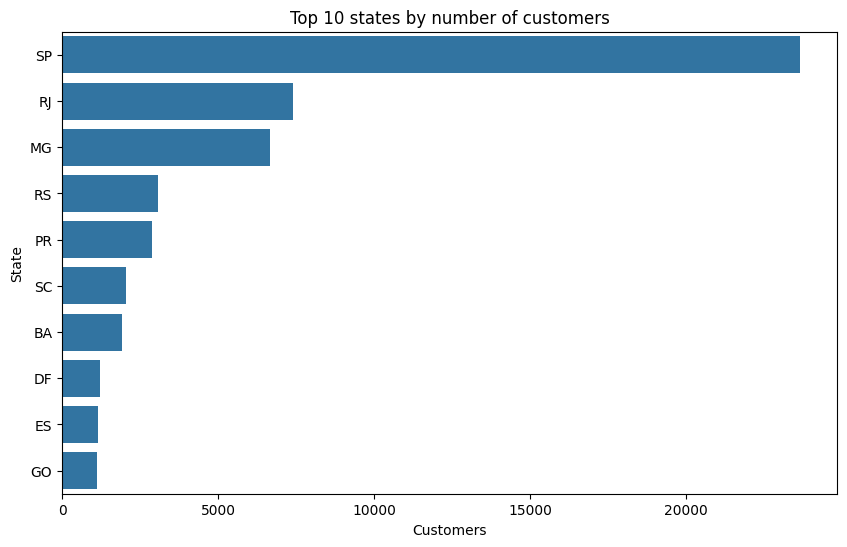

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_customers,
    x='customer_unique_id',
    y='customer_state'
)

plt.title('Top 10 states by number of customers')
plt.xlabel('Customers')
plt.ylabel('State')
plt.show()

In [19]:
# delivery mean time / среднее время доставки
print(
    f"Average delivery time: "
    f"{df['delivery_days'].mean():.2f} days"
)

Average delivery time: 12.47 days


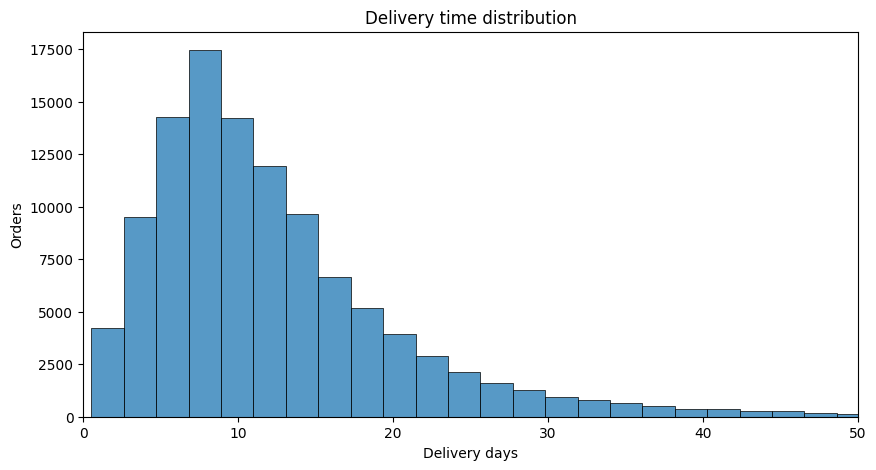

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['delivery_days'].dropna(),
    bins=100
)

plt.xlim(0, 50)
plt.title('Delivery time distribution')
plt.xlabel('Delivery days')
plt.ylabel('Orders')
plt.show()

In [21]:
# delays / задержки
late_rate = df.groupby('order_id')['is_late'].first().mean() * 100

print(f"Late delivery rate: {late_rate:.2f}%")

Late delivery rate: 7.87%


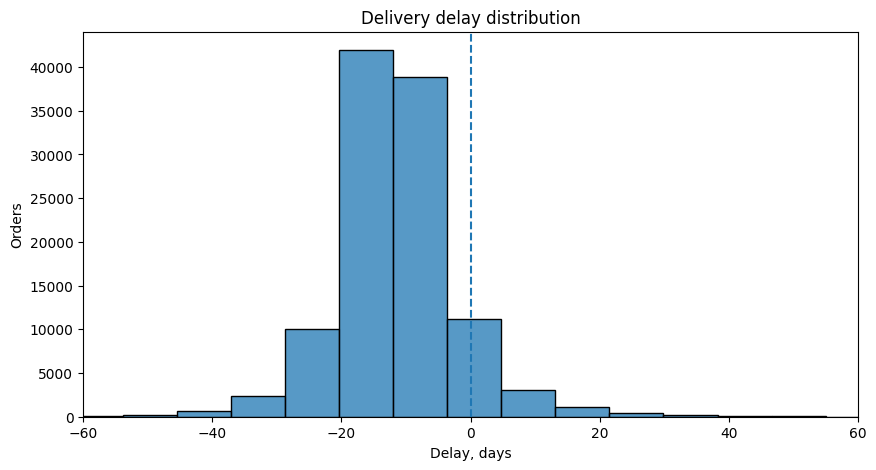

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['delivery_delay_days'].dropna(),
    bins=40
)

plt.axvline(0, linestyle='--')
plt.xlim(-60, 60)
plt.title('Delivery delay distribution')
plt.xlabel('Delay, days')
plt.ylabel('Orders')
plt.show()


In [23]:
# correlation / корреляция
order_level = (
    df.groupby('order_id')
    .agg(
        order_value=('price', 'sum'),
        delivery_days=('delivery_days', 'first'),
        delivery_delay_days=('delivery_delay_days', 'first')
    )
    .reset_index()
)

order_level[
    ['order_value', 'delivery_days', 'delivery_delay_days']
].corr()

,order_value,delivery_days,delivery_delay_days
order_value,1.000000,0.055578,-0.013659
delivery_days,0.055578,1.000000,0.607221
delivery_delay_days,-0.013659,0.607221,1.000000


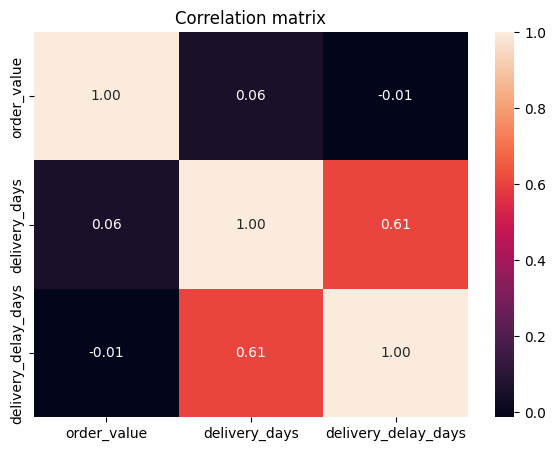

In [24]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    order_level[
        ['order_value', 'delivery_days', 'delivery_delay_days']
    ].corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation matrix')
plt.show()

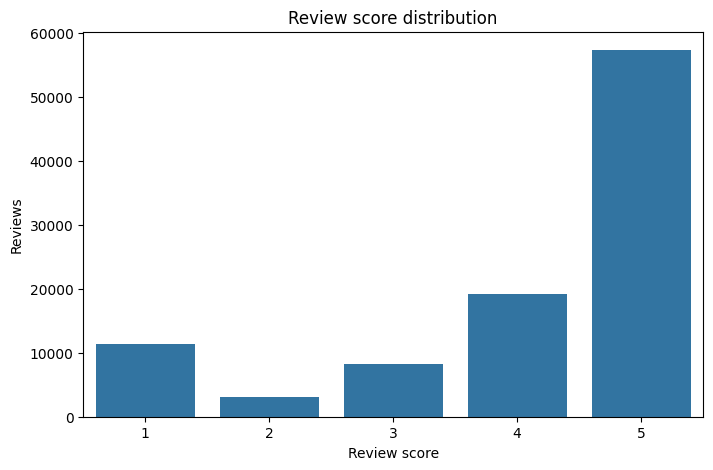

In [25]:
# reviews / отзывы
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
# distribution / распределение
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x='review_score'
)

plt.title('Review score distribution')
plt.xlabel('Review score')
plt.ylabel('Reviews')
plt.show()

In [26]:
# mean rating / средняя оценка
print(
    f"Average review score: "
    f"{reviews['review_score'].mean():.2f}"
)

Average review score: 4.09
